# Analisis Pengujian (Rata-rata 6 Run): Q-Learning vs Q-Learning Fuzzy vs HPA

Analisis komparatif hasil pengujian tiga metode autoscaling dengan merata-ratakan 6 run eksperimen dari `data-testing/19-02-2026/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import glob
import os

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

DATA_DIR = 'data-testing/19-02-2026'

# Load all 6 CSVs per method
ql_files  = sorted(glob.glob(f'{DATA_DIR}/q-learning/test_Q-LEARNING_*.csv'))
qf_files  = sorted(glob.glob(f'{DATA_DIR}/q-learning-fuzzy/test_Q-LEARNING-FUZZY_*.csv'))
hpa_files = sorted(glob.glob(f'{DATA_DIR}/hpa/metrics_*.csv'))

print(f'Q-Learning files      : {len(ql_files)}')
print(f'Q-Learning Fuzzy files: {len(qf_files)}')
print(f'HPA files             : {len(hpa_files)}')

NUMERIC_COLS = ['cpu_usage', 'memory_usage', 'response_time_ms',
                'request_rate_rps', 'replica_state', 'pod_count',
                'cpu_usage_cores', 'memory_usage_mb']


def load_and_align(files, label):
    """Load multiple CSVs, align by elapsed index, return list of DataFrames."""
    dfs = []
    for f in files:
        df = pd.read_csv(f, parse_dates=['timestamp'])
        df['elapsed_s'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
        df['elapsed_min'] = df['elapsed_s'] / 60.0
        dfs.append(df)
        print(f'  {os.path.basename(f)}: {len(df)} rows, {df["elapsed_s"].iloc[-1]:.0f}s')
    return dfs


print('\nLoading Q-Learning:')
ql_runs = load_and_align(ql_files, 'Q-Learning')
print('\nLoading Q-Learning Fuzzy:')
qf_runs = load_and_align(qf_files, 'Q-Learning Fuzzy')
print('\nLoading HPA:')
hpa_runs = load_and_align(hpa_files, 'HPA')

Q-Learning files      : 6
Q-Learning Fuzzy files: 6
HPA files             : 6

Loading Q-Learning:
  test_Q-LEARNING_20260221_192803.csv: 121 rows, 1862s
  test_Q-LEARNING_20260221_200210.csv: 123 rows, 1871s
  test_Q-LEARNING_20260221_203652.csv: 122 rows, 1862s
  test_Q-LEARNING_20260221_211202.csv: 122 rows, 1861s
  test_Q-LEARNING_20260221_221533.csv: 122 rows, 1860s
  test_Q-LEARNING_20260221_225653.csv: 123 rows, 1873s

Loading Q-Learning Fuzzy:
  test_Q-LEARNING-FUZZY_20260221_192707.csv: 128 rows, 1953s
  test_Q-LEARNING-FUZZY_20260221_200234.csv: 127 rows, 1933s
  test_Q-LEARNING-FUZZY_20260221_203547.csv: 126 rows, 1923s
  test_Q-LEARNING-FUZZY_20260221_211239.csv: 127 rows, 1939s
  test_Q-LEARNING-FUZZY_20260221_221443.csv: 127 rows, 1937s
  test_Q-LEARNING-FUZZY_20260221_225713.csv: 132 rows, 2012s

Loading HPA:
  metrics_20260221_233530.csv: 123 rows, 1988s
  metrics_20260221_233600.csv: 123 rows, 1989s
  metrics_20260222_001647.csv: 126 rows, 1920s
  metrics_20260222_0017

In [2]:
def average_runs(dfs, numeric_cols=NUMERIC_COLS):
    """
    Rata-ratakan beberapa run berdasarkan indeks baris.
    Trim semua ke panjang minimum, kemudian rata-ratakan tiap kolom numerik.
    """
    min_rows = min(len(df) for df in dfs)
    trimmed = [df.iloc[:min_rows].reset_index(drop=True) for df in dfs]

    avg = trimmed[0][['elapsed_s', 'elapsed_min']].copy()
    for col in numeric_cols:
        stacked = pd.concat([df[col] for df in trimmed], axis=1)
        avg[col] = stacked.mean(axis=1)

    print(f'  Trimmed to {min_rows} rows, averaged {len(dfs)} runs')
    return avg


print('Averaging runs:')
print('  Q-Learning:')
df_ql = average_runs(ql_runs)
print('  Q-Learning Fuzzy:')
df_qf = average_runs(qf_runs)
print('  HPA:')
df_hpa = average_runs(hpa_runs)

# Color / label scheme
COLORS = {'ql': '#26A69A', 'qf': '#5C6BC0', 'hpa': '#FF7043'}
LABELS = {'ql': 'Q-Learning', 'qf': 'Q-Learning Fuzzy', 'hpa': 'HPA'}

print('\nAveraged dataset summary:')
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    print(f'  {LABELS[key]:<22}: {len(df)} rows, {df["elapsed_s"].iloc[-1]:.0f}s duration')

Averaging runs:
  Q-Learning:
  Trimmed to 121 rows, averaged 6 runs
  Q-Learning Fuzzy:
  Trimmed to 126 rows, averaged 6 runs
  HPA:
  Trimmed to 123 rows, averaged 6 runs

Averaged dataset summary:
  Q-Learning            : 121 rows, 1862s duration
  Q-Learning Fuzzy      : 126 rows, 1923s duration
  HPA                   : 123 rows, 1988s duration


## 6.1.7 Hasil SLO Response Time Selama Pengujian

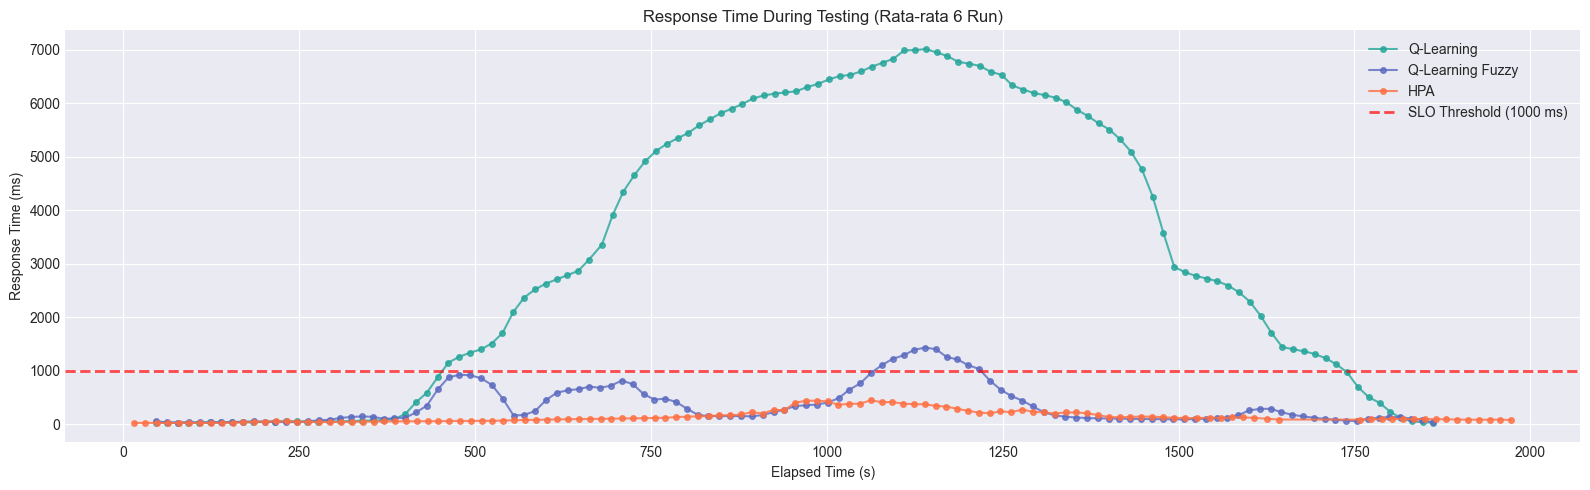

                    Response Time Statistics (ms)                     
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                  3226.4   2748.7     30.2   7012.5   2610.8
Q-Learning Fuzzy             357.4    168.4     33.2   1432.6    367.1
HPA                          145.6    102.7     26.0    448.6    113.5


In [3]:
SLO_THRESHOLD = 1000  # ms

# --- Response Time Line Chart ---
fig, ax = plt.subplots(figsize=(16, 5))

for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_s'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=4, linewidth=1.5, label=LABELS[key], color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time During Testing (Rata-rata 6 Run)')
ax.legend()

plt.tight_layout()
plt.show()

# Response Time Statistics
print(f'{"Response Time Statistics (ms)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    valid = df.loc[df['response_time_ms'].notna() & (df['response_time_ms'] > 0), 'response_time_ms']
    if len(valid) > 0:
        print(f'{LABELS[key]:<25} {valid.mean():>8.1f} {valid.median():>8.1f} {valid.min():>8.1f} {valid.max():>8.1f} {valid.std():>8.1f}')
    else:
        print(f'{LABELS[key]:<25} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8}')

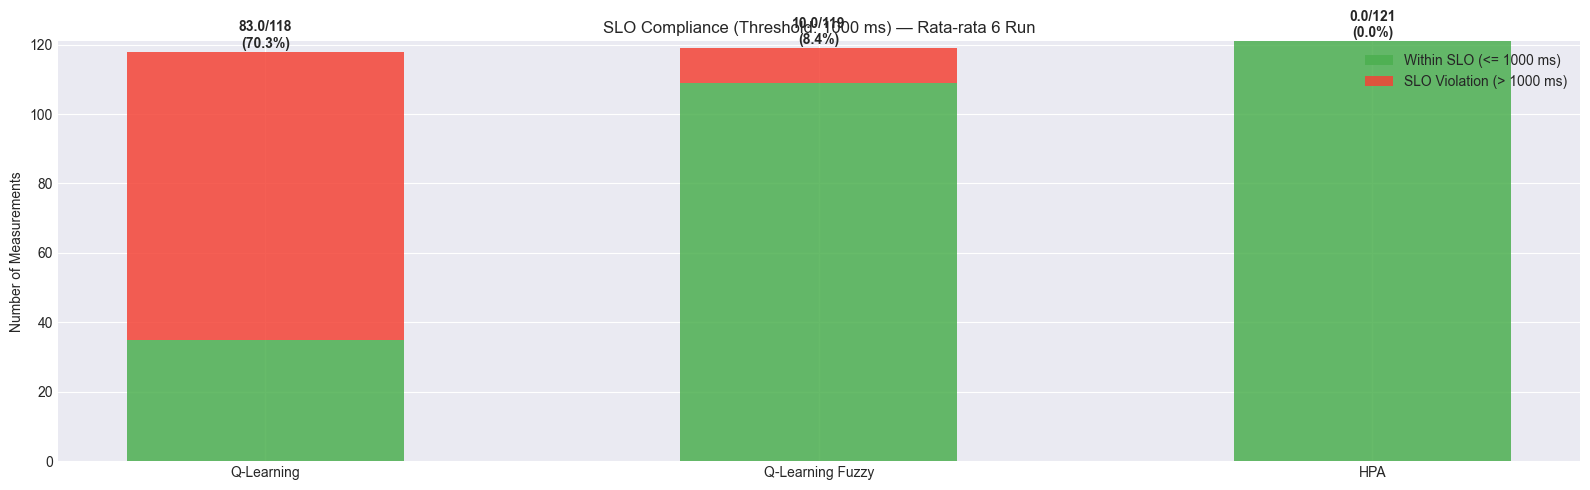


                      SLO RESPONSE TIME SUMMARY                       
Method                       Total   Within SLO   Violations  Violation %
----------------------------------------------------------------------
Q-Learning                     118         35.0         83.0        70.3%
Q-Learning Fuzzy               119        109.0         10.0         8.4%
HPA                            121        121.0          0.0         0.0%


In [4]:
# --- SLO Violation Count ---
fig, ax = plt.subplots(figsize=(16, 5))

violations = {}
totals = {}
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    over_slo = (df.loc[valid, 'response_time_ms'] > SLO_THRESHOLD).sum()
    violations[LABELS[key]] = over_slo
    totals[LABELS[key]] = total

labels_list = list(violations.keys())
violation_counts = list(violations.values())
total_counts = [totals[l] for l in labels_list]
within_counts = [t - v for t, v in zip(total_counts, violation_counts)]

x = np.arange(len(labels_list))
width = 0.5

ax.bar(x, within_counts, width, label=f'Within SLO (<= {SLO_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violation_counts, width, bottom=within_counts, label=f'SLO Violation (> {SLO_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i, (v, t) in enumerate(zip(violation_counts, total_counts)):
    pct = v / t * 100 if t > 0 else 0
    ax.text(i, t + 0.3, f'{v:.1f}/{t}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Number of Measurements')
ax.set_title(f'SLO Compliance (Threshold: {SLO_THRESHOLD} ms) — Rata-rata 6 Run')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.legend()

plt.tight_layout()
plt.show()

# SLO Summary Table
print(f'\n{"=" * 70}')
print(f'{"SLO RESPONSE TIME SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Total":>8} {"Within SLO":>12} {"Violations":>12} {"Violation %":>12}')
print(f'{"-" * 70}')
for label in labels_list:
    t = totals[label]
    v = violations[label]
    w = t - v
    pct = v / t * 100 if t > 0 else 0
    print(f'{label:<25} {t:>8} {w:>12.1f} {v:>12.1f} {pct:>11.1f}%')

## 6.1.8 Hasil Utilisasi CPU dan Memori Selama Pengujian

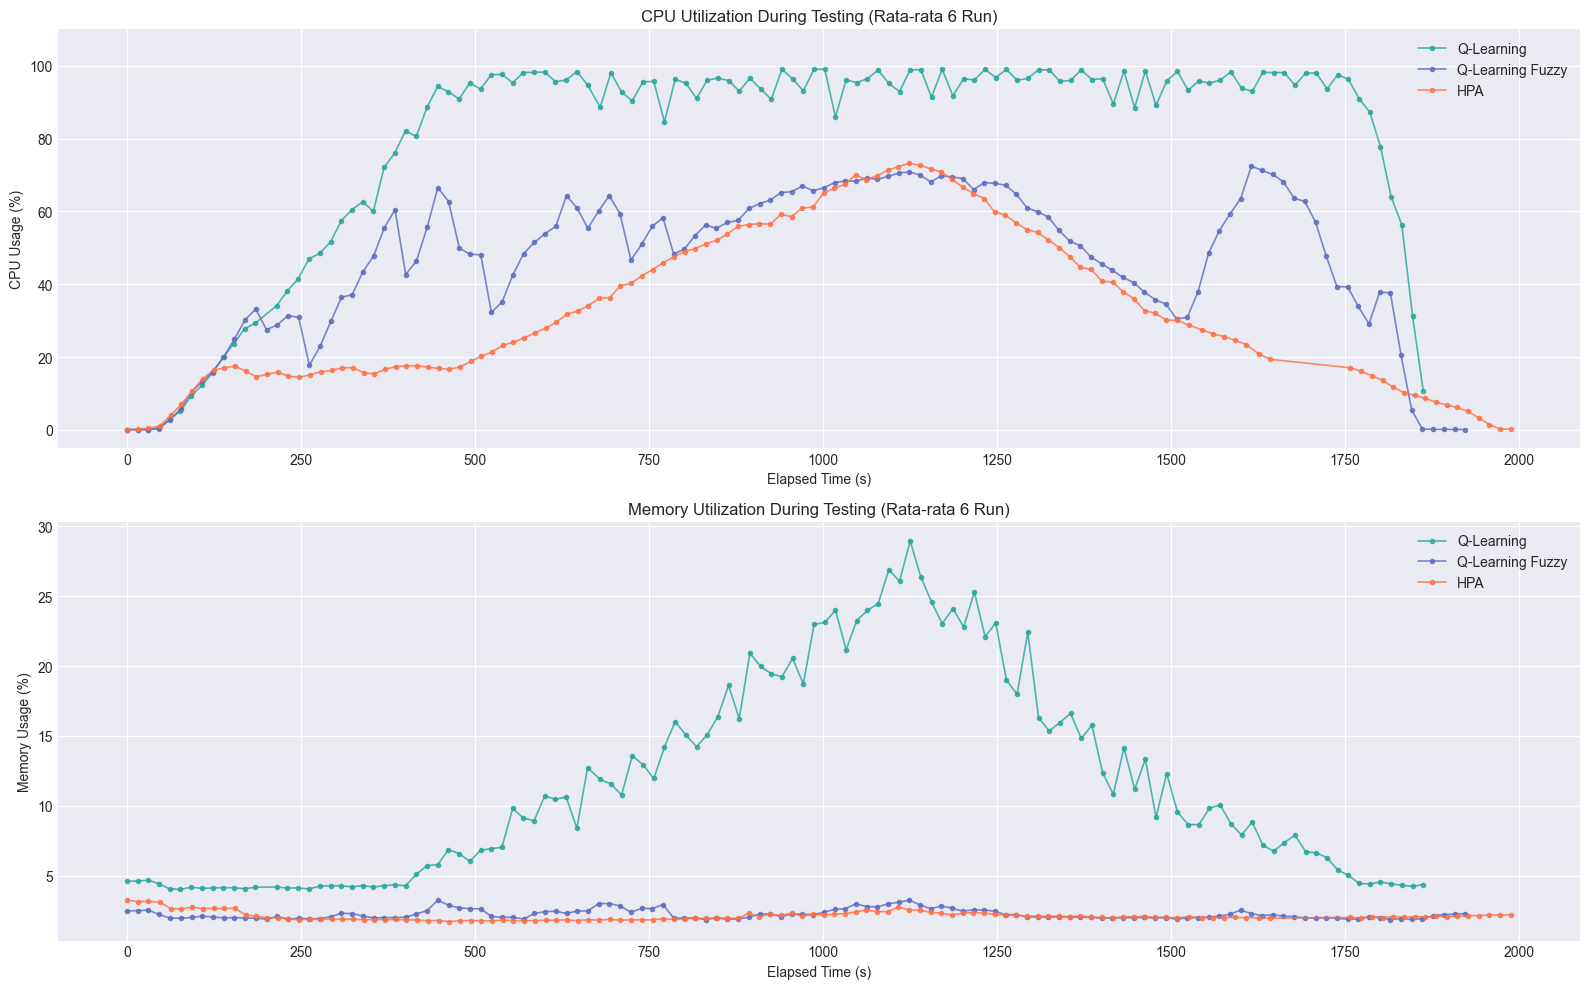


                   CPU & MEMORY UTILIZATION SUMMARY                   

                            CPU Usage (%)                             
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                   80.00    94.76    0.080    99.06    29.23
Q-Learning Fuzzy             46.17    50.77    0.086    72.45    20.78
HPA                          32.80    27.42    0.073    73.23    21.71

                           Memory Usage (%)                           
----------------------------------------------------------------------
Method                        Mean   Median      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                   11.58     9.56    4.011    28.95     7.18
Q-Learning Fuzzy              2.24     2.09    1.851     3.24     0.34
HPA

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: CPU Usage ---
ax = axes[0]
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    ax.plot(df['elapsed_s'], df['cpu_usage'], marker='o', markersize=3, linewidth=1.2,
            label=LABELS[key], color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('CPU Usage (%)')
ax.set_title('CPU Utilization During Testing (Rata-rata 6 Run)')
ax.set_ylim(-5, 110)
ax.legend()

# --- Bottom: Memory Usage ---
ax = axes[1]
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    ax.plot(df['elapsed_s'], df['memory_usage'], marker='o', markersize=3, linewidth=1.2,
            label=LABELS[key], color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Memory Usage (%)')
ax.set_title('Memory Utilization During Testing (Rata-rata 6 Run)')
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f'\n{"=" * 70}')
print(f'{"CPU & MEMORY UTILIZATION SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'\n{"CPU Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    cpu = df['cpu_usage']
    print(f'{LABELS[key]:<25} {cpu.mean():>8.2f} {cpu.median():>8.2f} {cpu.min():>8.3f} {cpu.max():>8.2f} {cpu.std():>8.2f}')

print(f'\n{"Memory Usage (%)":^70}')
print(f'{"-" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Median":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    mem = df['memory_usage']
    print(f'{LABELS[key]:<25} {mem.mean():>8.2f} {mem.median():>8.2f} {mem.min():>8.3f} {mem.max():>8.2f} {mem.std():>8.2f}')

## 6.1.9 Hasil Jumlah Replica Selama Pengujian

C:\Users\indra\AppData\Local\Temp\ipykernel_10180\1037186282.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)


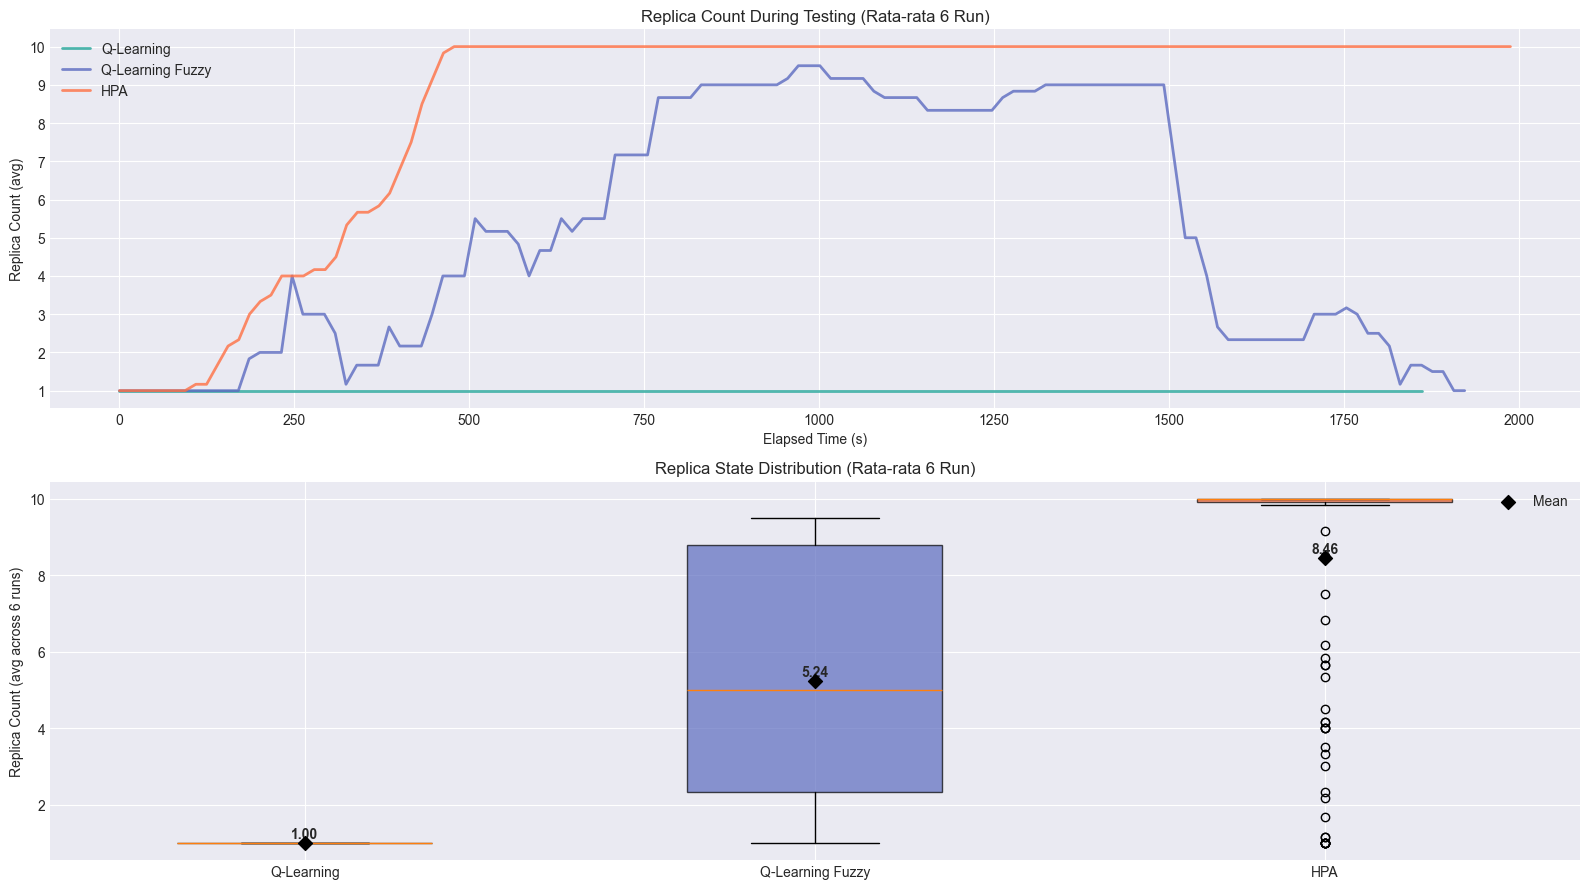


                        REPLICA COUNT SUMMARY                         
Method                        Mean      Min      Max      Std
----------------------------------------------------------------------
Q-Learning                    1.00     1.00     1.00     0.00
Q-Learning Fuzzy              5.24     1.00     9.50     3.19
HPA                           8.46     1.00    10.00     2.97


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# --- Top: Replica count over time ---
ax = axes[0]
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    ax.plot(df['elapsed_s'], df['replica_state'], linewidth=2,
            label=LABELS[key], color=COLORS[key], alpha=0.8)

ax.set_xlabel('Elapsed Time (s)')
ax.set_ylabel('Replica Count (avg)')
ax.set_title('Replica Count During Testing (Rata-rata 6 Run)')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False))
ax.legend()

# --- Bottom: Replica distribution box plot (since avg gives continuous values) ---
ax = axes[1]
datasets = [('ql', df_ql, LABELS['ql']), ('qf', df_qf, LABELS['qf']), ('hpa', df_hpa, LABELS['hpa'])]

bp_data = [df['replica_state'] for _, df, _ in datasets]
bp_labels = [label for _, _, label in datasets]
bp_colors_list = [COLORS[key] for key, _, _ in datasets]

bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], bp_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

means = [d.mean() for d in bp_data]
ax.scatter(range(1, 4), means, color='black', marker='D', s=50, zorder=5, label='Mean')
for i, m in enumerate(means):
    ax.text(i + 1, m + 0.05, f'{m:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Replica Count (avg across 6 runs)')
ax.set_title('Replica State Distribution (Rata-rata 6 Run)')
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print(f'\n{"=" * 70}')
print(f'{"REPLICA COUNT SUMMARY":^70}')
print(f'{"=" * 70}')
print(f'{"Method":<25} {"Mean":>8} {"Min":>8} {"Max":>8} {"Std":>8}')
print(f'{"-" * 70}')
for key, df, label in datasets:
    rep = df['replica_state']
    print(f'{label:<25} {rep.mean():>8.2f} {rep.min():>8.2f} {rep.max():>8.2f} {rep.std():>8.2f}')

## 6.1.10 Analisis Efisiensi Sumber Daya: Overprovisioning vs Underprovisioning

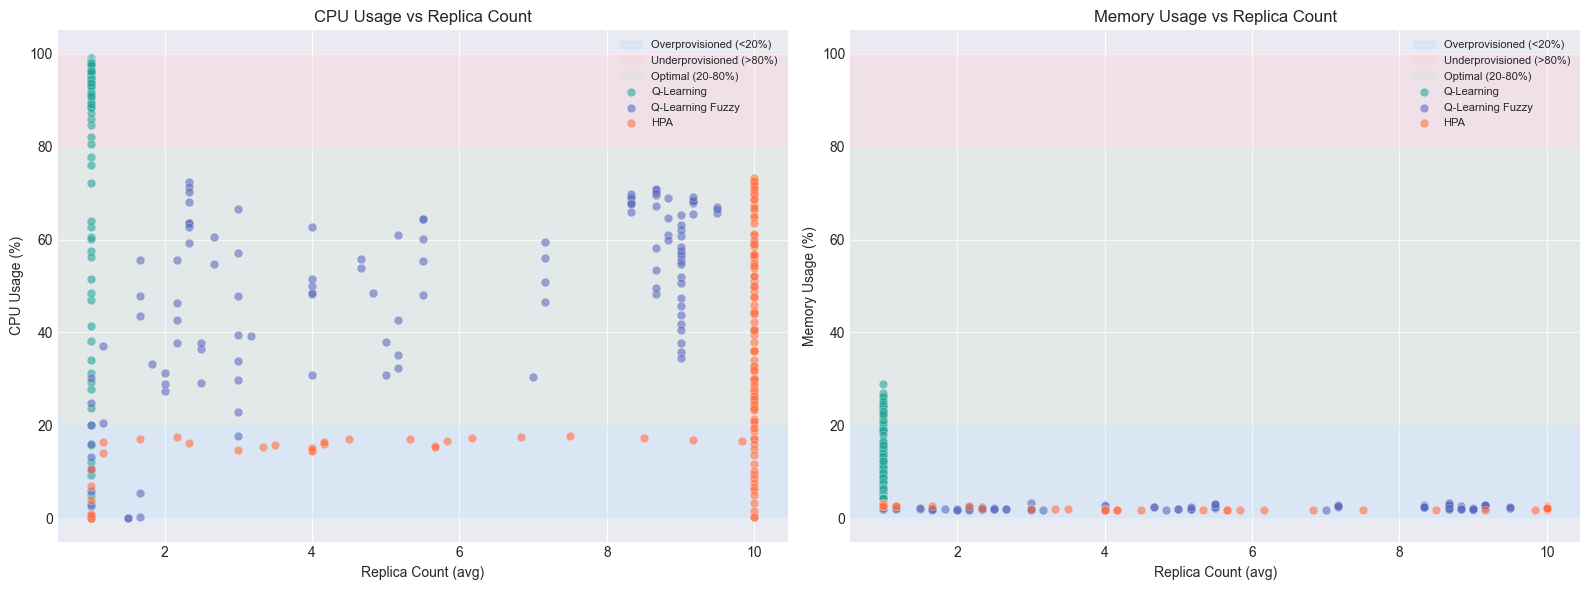

C:\Users\indra\AppData\Local\Temp\ipykernel_10180\1905982473.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
C:\Users\indra\AppData\Local\Temp\ipykernel_10180\1905982473.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)


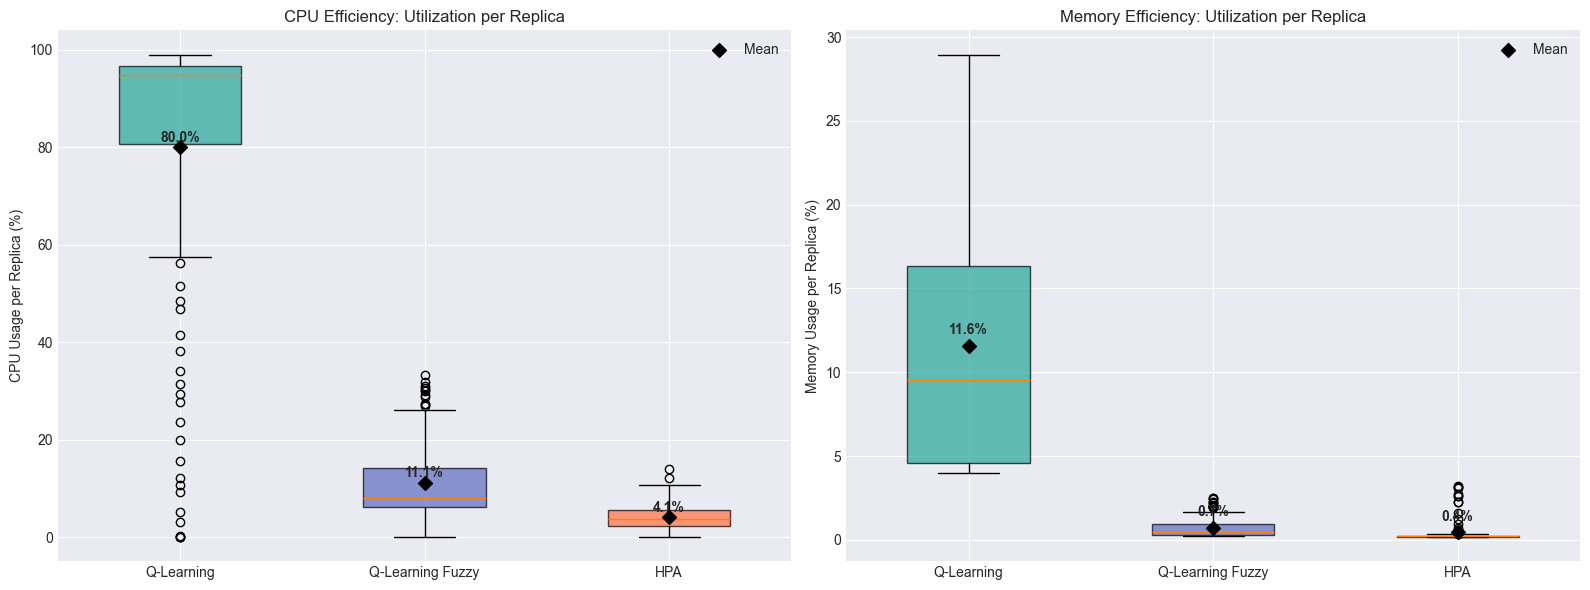

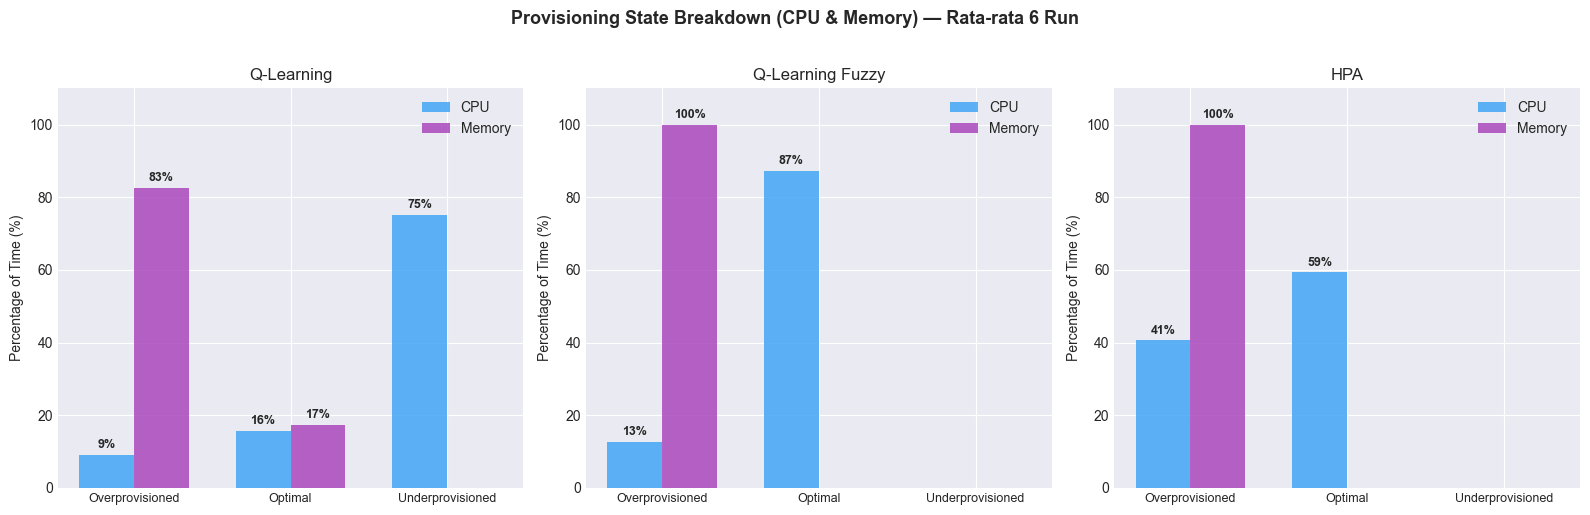


                          RESOURCE EFFICIENCY SUMMARY                           

Method                Avg Replica   Avg CPU   Avg MEM   CPU/Rep   MEM/Rep
--------------------------------------------------------------------------------
Q-Learning                   1.00    80.00%    11.58%    80.00%    11.58%
Q-Learning Fuzzy             5.24    46.17%     2.24%     8.80%     0.43%
HPA                          8.46    32.80%     2.10%     3.88%     0.25%

                             Provisioning Breakdown                             
--------------------------------------------------------------------------------
Method                Over (CPU)   Opt (CPU)  Under (CPU)  Over (MEM)   Opt (MEM)  Under (MEM)
--------------------------------------------------------------------------------
Q-Learning                  9.1%       15.7%        75.2%       82.6%       17.4%         0.0%
Q-Learning Fuzzy           12.7%       87.3%         0.0%      100.0%        0.0%         0.0%
HPA        

In [7]:
# Overprovisioning/Underprovisioning thresholds
CPU_LOW, CPU_HIGH = 20, 80
MEM_LOW, MEM_HIGH = 20, 80

datasets = [('ql', df_ql, LABELS['ql']), ('qf', df_qf, LABELS['qf']), ('hpa', df_hpa, LABELS['hpa'])]

# --- 1) CPU & Memory vs Replica (scatter) with provisioning zones ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, label_y in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU Usage (%)', 'Memory Usage (%)']):
    ax.axhspan(0, CPU_LOW, color='#BBDEFB', alpha=0.3, label=f'Overprovisioned (<{CPU_LOW}%)')
    ax.axhspan(CPU_HIGH, 100, color='#FFCDD2', alpha=0.3, label=f'Underprovisioned (>{CPU_HIGH}%)')
    ax.axhspan(CPU_LOW, CPU_HIGH, color='#C8E6C9', alpha=0.2, label=f'Optimal ({CPU_LOW}-{CPU_HIGH}%)')

    for key, df, label in datasets:
        ax.scatter(df['replica_state'], df[metric], s=40, alpha=0.6,
                   color=COLORS[key], label=label, edgecolors='white', linewidth=0.3)

    ax.set_xlabel('Replica Count (avg)')
    ax.set_ylabel(label_y)
    ax.set_title(f'{label_y.split(" (")[0]} vs Replica Count')
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# --- 2) Utilisasi per Replica (efisiensi) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ['cpu_usage', 'memory_usage'], ['CPU', 'Memory']):
    summary_data = {}
    for key, df, label in datasets:
        efficiency = df[metric] / df['replica_state']
        summary_data[label] = efficiency

    bp_data = [summary_data[LABELS[k]] for k in ['ql', 'qf', 'hpa']]
    bp_labels = [LABELS[k] for k in ['ql', 'qf', 'hpa']]
    bp_colors_list = [COLORS[k] for k in ['ql', 'qf', 'hpa']]

    bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], bp_colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    means = [d.mean() for d in bp_data]
    ax.scatter(range(1, 4), means, color='black', marker='D', s=50, zorder=5, label='Mean')
    for i, m in enumerate(means):
        ax.text(i + 1, m + 0.5, f'{m:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel(f'{title} Usage per Replica (%)')
    ax.set_title(f'{title} Efficiency: Utilization per Replica')
    ax.legend()

plt.tight_layout()
plt.show()

# --- 3) Provisioning category breakdown per method ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (key, df, label) in zip(axes, datasets):
    over_cpu  = (df['cpu_usage'] < CPU_LOW).sum()
    opt_cpu   = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    under_cpu = (df['cpu_usage'] > CPU_HIGH).sum()

    over_mem  = (df['memory_usage'] < MEM_LOW).sum()
    opt_mem   = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    under_mem = (df['memory_usage'] > MEM_HIGH).sum()

    categories = ['Overprovisioned', 'Optimal', 'Underprovisioned']
    x = np.arange(len(categories))
    width = 0.35
    total = len(df)

    cpu_pcts = [over_cpu/total*100, opt_cpu/total*100, under_cpu/total*100]
    mem_pcts = [over_mem/total*100, opt_mem/total*100, under_mem/total*100]

    bars1 = ax.bar(x - width/2, cpu_pcts, width, label='CPU', color='#42A5F5', alpha=0.85)
    bars2 = ax.bar(x + width/2, mem_pcts, width, label='Memory', color='#AB47BC', alpha=0.85)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 1,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel('Percentage of Time (%)')
    ax.set_title(f'{label}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 110)
    ax.legend()

fig.suptitle('Provisioning State Breakdown (CPU & Memory) — Rata-rata 6 Run',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 4) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"RESOURCE EFFICIENCY SUMMARY":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<20} {"Avg Replica":>12} {"Avg CPU":>9} {"Avg MEM":>9} {"CPU/Rep":>9} {"MEM/Rep":>9}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    avg_rep = df['replica_state'].mean()
    avg_cpu = df['cpu_usage'].mean()
    avg_mem = df['memory_usage'].mean()
    cpu_per_rep = avg_cpu / avg_rep if avg_rep > 0 else 0
    mem_per_rep = avg_mem / avg_rep if avg_rep > 0 else 0
    print(f'{label:<20} {avg_rep:>12.2f} {avg_cpu:>8.2f}% {avg_mem:>8.2f}% {cpu_per_rep:>8.2f}% {mem_per_rep:>8.2f}%')

print(f'\n{"Provisioning Breakdown":^80}')
print(f'{"-" * 80}')
print(f'{"Method":<20} {"Over (CPU)":>11} {"Opt (CPU)":>11} {"Under (CPU)":>12} {"Over (MEM)":>11} {"Opt (MEM)":>11} {"Under (MEM)":>12}')
print(f'{"-" * 80}')
for key, df, label in datasets:
    t = len(df)
    oc   = (df['cpu_usage'] < CPU_LOW).sum()
    optc = ((df['cpu_usage'] >= CPU_LOW) & (df['cpu_usage'] <= CPU_HIGH)).sum()
    uc   = (df['cpu_usage'] > CPU_HIGH).sum()
    om   = (df['memory_usage'] < MEM_LOW).sum()
    optm = ((df['memory_usage'] >= MEM_LOW) & (df['memory_usage'] <= MEM_HIGH)).sum()
    um   = (df['memory_usage'] > MEM_HIGH).sum()
    print(f'{label:<20} {oc/t*100:>10.1f}% {optc/t*100:>10.1f}% {uc/t*100:>11.1f}% {om/t*100:>10.1f}% {optm/t*100:>10.1f}% {um/t*100:>11.1f}%')

## 6.1.11 Load Pattern vs Replica & Response Time Selama Pengujian

Visualisasi gabungan yang menunjukkan bagaimana pola beban (k6 VUs) memengaruhi jumlah replica dan response time untuk ketiga metode autoscaling selama ~30 menit pengujian (rata-rata 6 run).

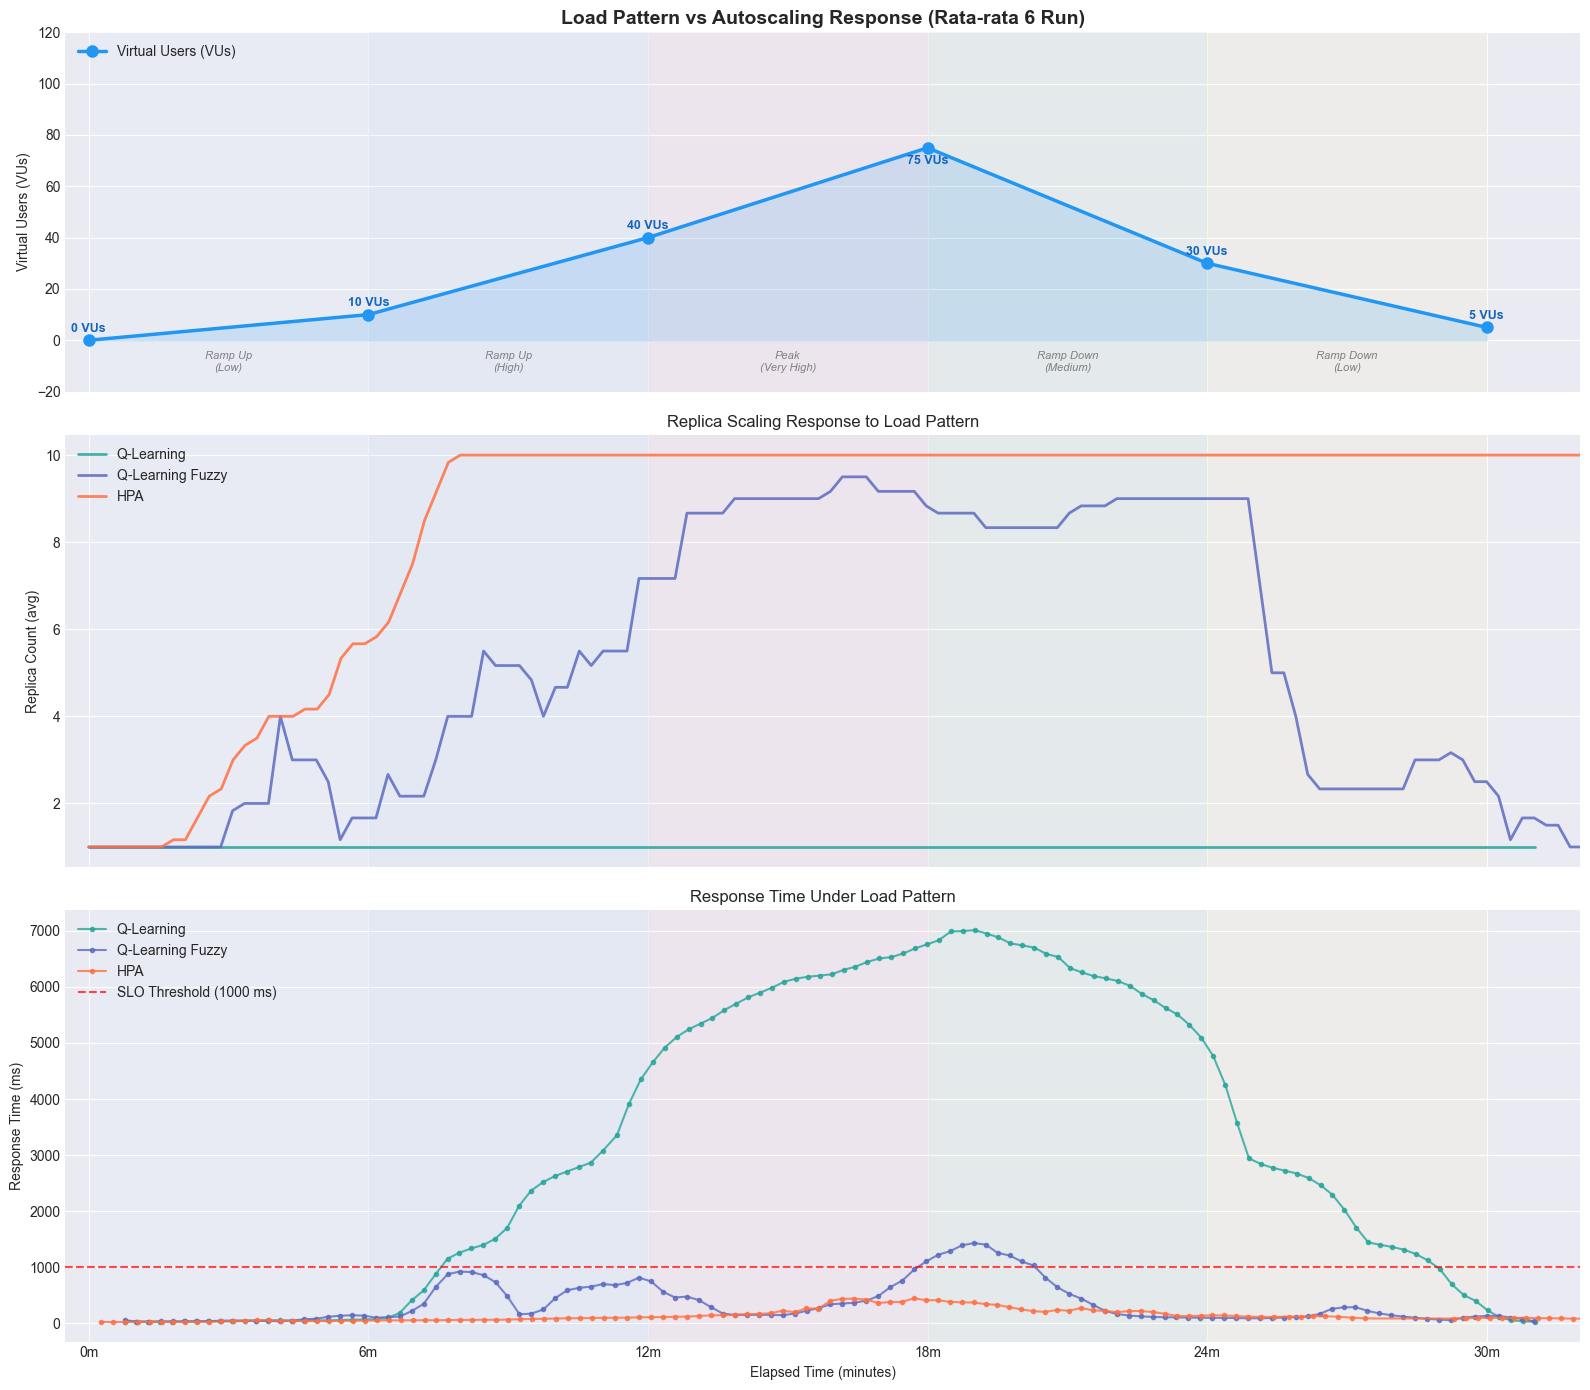


                        LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY                        

  Stage: 0-6m (0->10 VUs)
  Method                  Avg Replica  Avg RT (ms)  Max RT (ms)  SLO Violations
  ---------------------------------------------------------------------------
  Q-Learning                     1.00         45.8         71.4          0.0/20
  Q-Learning Fuzzy               1.66         64.2        146.7          0.0/21
  HPA                            2.78         38.0         54.0          0.0/23

  Stage: 6-12m (10->40 VUs)
  Method                  Avg Replica  Avg RT (ms)  Max RT (ms)  SLO Violations
  ---------------------------------------------------------------------------
  Q-Learning                     1.00       1881.4       4350.2         17.0/23
  Q-Learning Fuzzy               4.32        530.8        924.9          0.0/23
  HPA                            9.30         75.8        108.8          0.0/23

  Stage: 12-18m (40->75 VUs)
  Method                  

In [8]:
# k6 ramping-vus stages (from k6-train-patterns-loop.js)
k6_stages = [
    {"duration_min": 6, "target": 10},
    {"duration_min": 6, "target": 40},
    {"duration_min": 6, "target": 75},
    {"duration_min": 6, "target": 30},
    {"duration_min": 6, "target": 5},
]

k6_times_min = [0]
k6_vus = [0]
t = 0
for stage in k6_stages:
    t += stage["duration_min"]
    k6_times_min.append(t)
    k6_vus.append(stage["target"])

# Stage colors
stage_colors = ['#E3F2FD', '#BBDEFB', '#FFCDD2', '#C8E6C9', '#FFF9C4', '#F3E5F5']
stage_labels = ['Ramp Up\n(Low)', 'Ramp Up\n(High)', 'Peak\n(Very High)',
                 'Ramp Down\n(Medium)', 'Ramp Down\n(Low)', 'Cool\nDown']

# --- Combined 3-panel figure ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1.2, 1.2]})

for ax in axes:
    for i in range(len(k6_stages)):
        ax.axvspan(k6_times_min[i], k6_times_min[i+1], alpha=0.15, color=stage_colors[i])

# ---- Panel 1: Load Pattern (VUs) ----
ax = axes[0]
ax.plot(k6_times_min, k6_vus, marker='o', linewidth=2.5, color='#2196F3',
        markersize=8, zorder=3, label='Virtual Users (VUs)')
ax.fill_between(k6_times_min, k6_vus, alpha=0.15, color='#2196F3')

for i, (t_val, v) in enumerate(zip(k6_times_min, k6_vus)):
    offset_y = 6 if v != max(k6_vus) else -12
    ax.annotate(f'{v} VUs', (t_val, v), textcoords='offset points',
                xytext=(0, offset_y), ha='center', fontsize=9, fontweight='bold', color='#1565C0')

for i in range(len(k6_stages)):
    mid = (k6_times_min[i] + k6_times_min[i+1]) / 2
    ax.text(mid, -12, stage_labels[i], ha='center', fontsize=8, style='italic', color='gray')

ax.set_ylabel('Virtual Users (VUs)')
ax.set_title('Load Pattern vs Autoscaling Response (Rata-rata 6 Run)', fontsize=14, fontweight='bold')
ax.set_ylim(-20, 120)
ax.legend(loc='upper left')

# ---- Panel 2: Replica Count ----
ax = axes[1]
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    ax.plot(df['elapsed_min'], df['replica_state'], linewidth=2,
            label=LABELS[key], color=COLORS[key], alpha=0.85)

ax.set_ylabel('Replica Count (avg)')
ax.set_title('Replica Scaling Response to Load Pattern')
ax.legend(loc='upper left')

# ---- Panel 3: Response Time ----
ax = axes[2]
SLO_THRESHOLD = 1000

for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
            marker='o', markersize=3, linewidth=1.5, label=LABELS[key], color=COLORS[key], alpha=0.8)

ax.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'SLO Threshold ({SLO_THRESHOLD} ms)')
ax.set_xlabel('Elapsed Time (minutes)')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time Under Load Pattern')
ax.legend(loc='upper left')

for ax in axes:
    ax.set_xticks(k6_times_min)
    ax.set_xticklabels([f'{t}m' for t in k6_times_min])
    ax.set_xlim(-0.5, max(k6_times_min) + 2)

plt.tight_layout()
plt.show()

# --- Summary: reaction per stage ---
print(f'\n{"=" * 90}')
print(f'{"LOAD STAGE vs AUTOSCALING RESPONSE SUMMARY":^90}')
print(f'{"=" * 90}')

stage_boundaries = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names = ['0-6m (0->10 VUs)', '6-12m (10->40 VUs)', '12-18m (40->75 VUs)',
               '18-24m (75->30 VUs)', '24-30m (30->5 VUs)']

for stage_name, (t_start, t_end) in zip(stage_names, stage_boundaries):
    print(f'\n  Stage: {stage_name}')
    print(f'  {"Method":<22} {"Avg Replica":>12} {"Avg RT (ms)":>12} {"Max RT (ms)":>12} {"SLO Violations":>15}')
    print(f'  {"-" * 75}')
    for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        stage_df = df.loc[mask]
        if len(stage_df) == 0:
            print(f'  {LABELS[key]:<22} {"N/A":>12} {"N/A":>12} {"N/A":>12} {"N/A":>15}')
            continue
        avg_rep = stage_df['replica_state'].mean()
        rt_valid = stage_df.loc[stage_df['response_time_ms'].notna() & (stage_df['response_time_ms'] > 0), 'response_time_ms']
        avg_rt = rt_valid.mean() if len(rt_valid) > 0 else 0
        max_rt = rt_valid.max() if len(rt_valid) > 0 else 0
        violations = (rt_valid > SLO_THRESHOLD).sum() if len(rt_valid) > 0 else 0
        total_valid = len(rt_valid)
        viol_str = f'{violations:.1f}/{total_valid}' if total_valid > 0 else 'N/A'
        print(f'  {LABELS[key]:<22} {avg_rep:>12.2f} {avg_rt:>12.1f} {max_rt:>12.1f} {viol_str:>15}')

## 6.1.12 Replica Count dengan Load Pattern Background

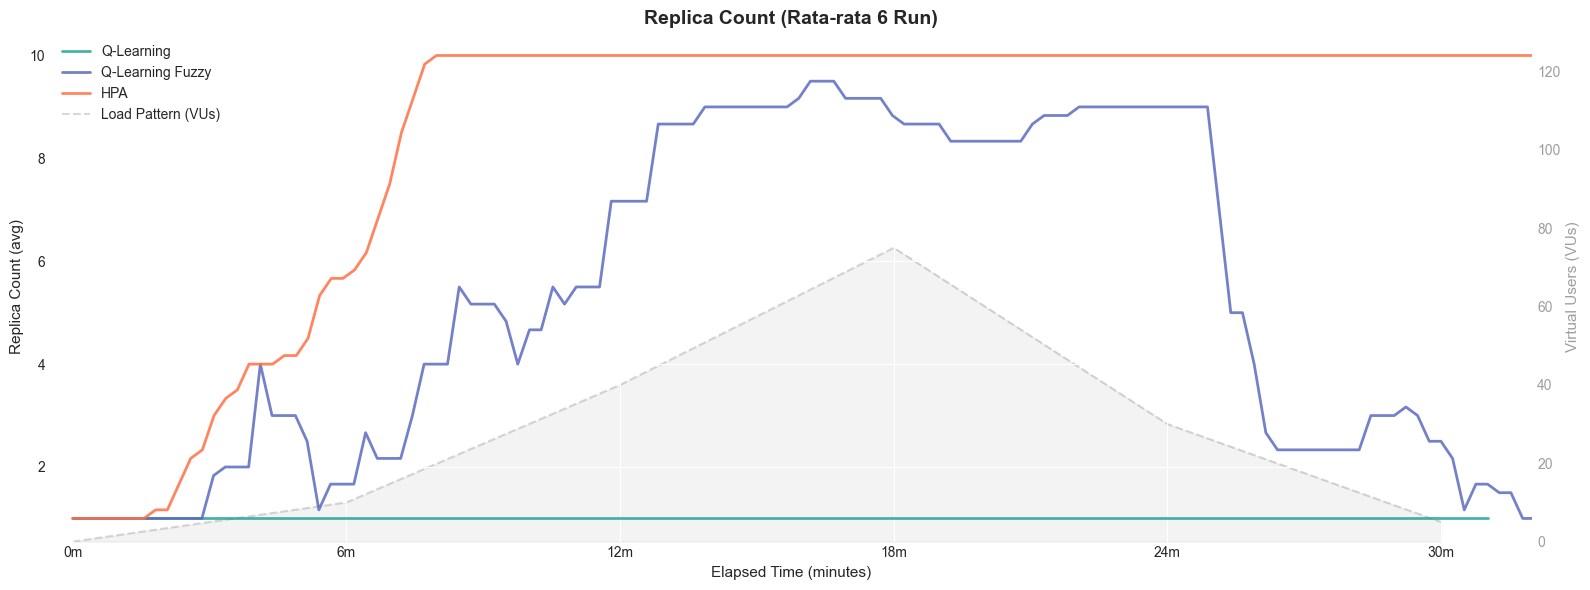

In [9]:
# --- Replica Count with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

ax2 = ax1.twinx()
ax2.fill_between(k6_times_min, k6_vus, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min, k6_vus, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, 130)

for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    ax1.plot(df['elapsed_min'], df['replica_state'], linewidth=2,
             label=LABELS[key], color=COLORS[key], alpha=0.85)

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('Replica Count (avg)', fontsize=11)
ax1.set_title('Replica Count (Rata-rata 6 Run)', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min)
ax1.set_xticklabels([f'{t}m' for t in k6_times_min])
ax1.set_xlim(-0.5, max(k6_times_min) + 2)

plt.tight_layout()
plt.show()

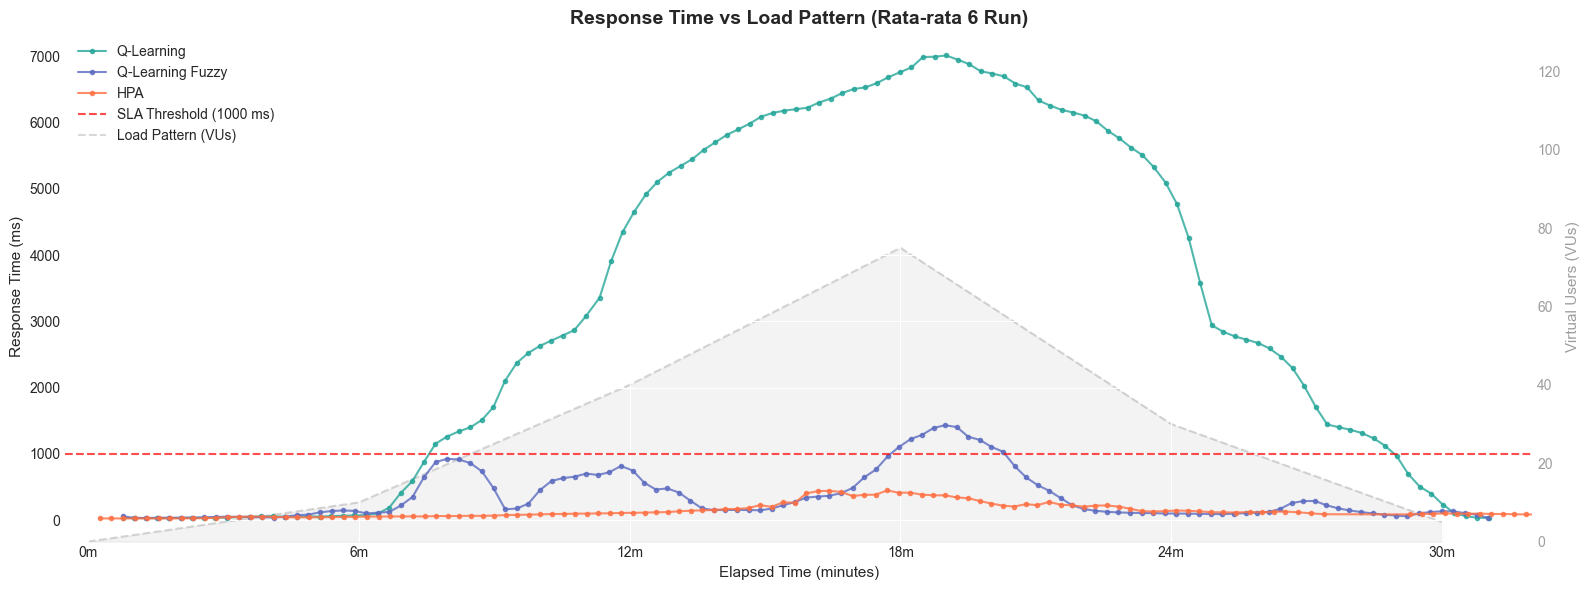

In [10]:
# --- Response Time with Load Pattern background (twinx) ---
fig, ax1 = plt.subplots(figsize=(16, 6))

ax2 = ax1.twinx()
ax2.fill_between(k6_times_min, k6_vus, alpha=0.12, color='#9E9E9E')
ax2.plot(k6_times_min, k6_vus, linewidth=1.5, color='#9E9E9E', alpha=0.4,
         linestyle='--', label='Load Pattern (VUs)')
ax2.set_ylabel('Virtual Users (VUs)', color='#9E9E9E', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#9E9E9E', labelsize=10)
ax2.set_ylim(0, 130)

SLO_THRESHOLD = 1000
for key, df in [('ql', df_ql), ('qf', df_qf), ('hpa', df_hpa)]:
    mask = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    ax1.plot(df.loc[mask, 'elapsed_min'], df.loc[mask, 'response_time_ms'],
             marker='o', markersize=3, linewidth=1.5, label=LABELS[key], color=COLORS[key], alpha=0.8)

ax1.axhline(y=SLO_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'SLA Threshold ({SLO_THRESHOLD} ms)')

ax1.set_xlabel('Elapsed Time (minutes)', fontsize=11)
ax1.set_ylabel('Response Time (ms)', fontsize=11)
ax1.set_title('Response Time vs Load Pattern (Rata-rata 6 Run)', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

ax1.set_xticks(k6_times_min)
ax1.set_xticklabels([f'{t}m' for t in k6_times_min])
ax1.set_xlim(-0.5, max(k6_times_min) + 2)

plt.tight_layout()
plt.show()

## 6.1.13 Analisis Pelanggaran SLA per Load Stage (Response Time > 1000ms)

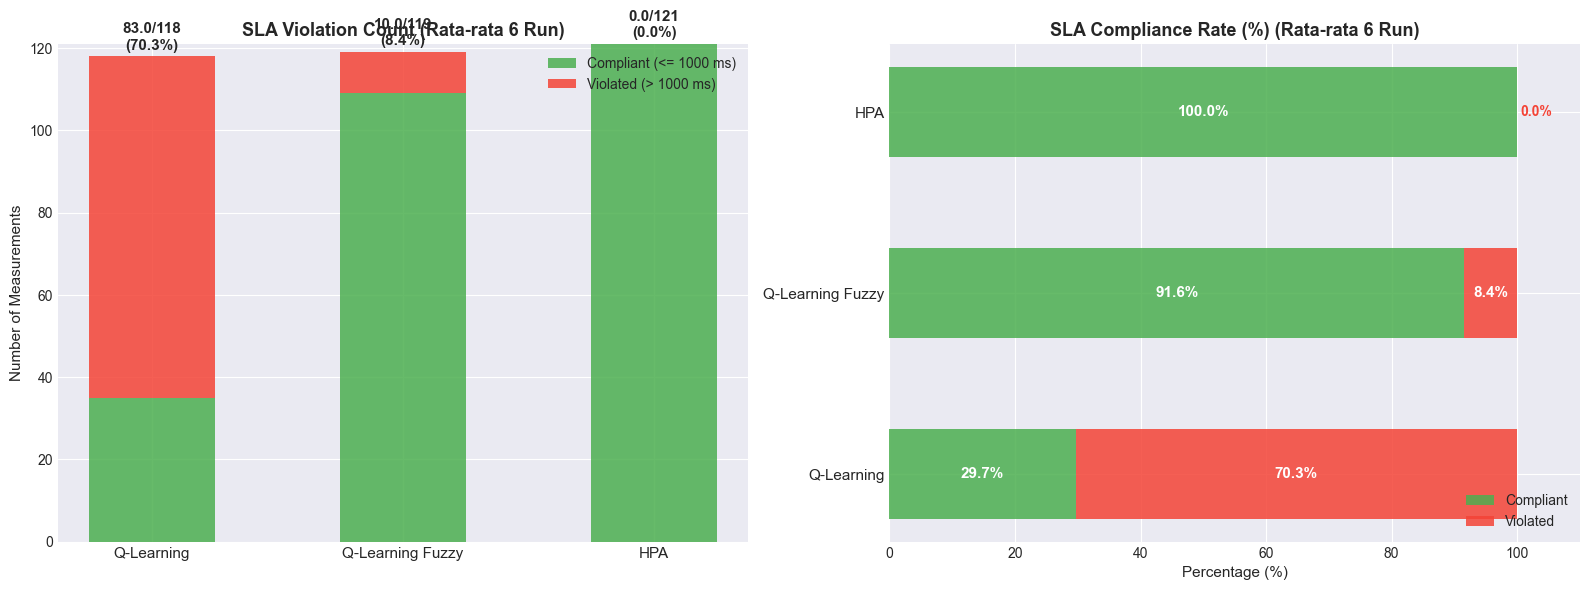

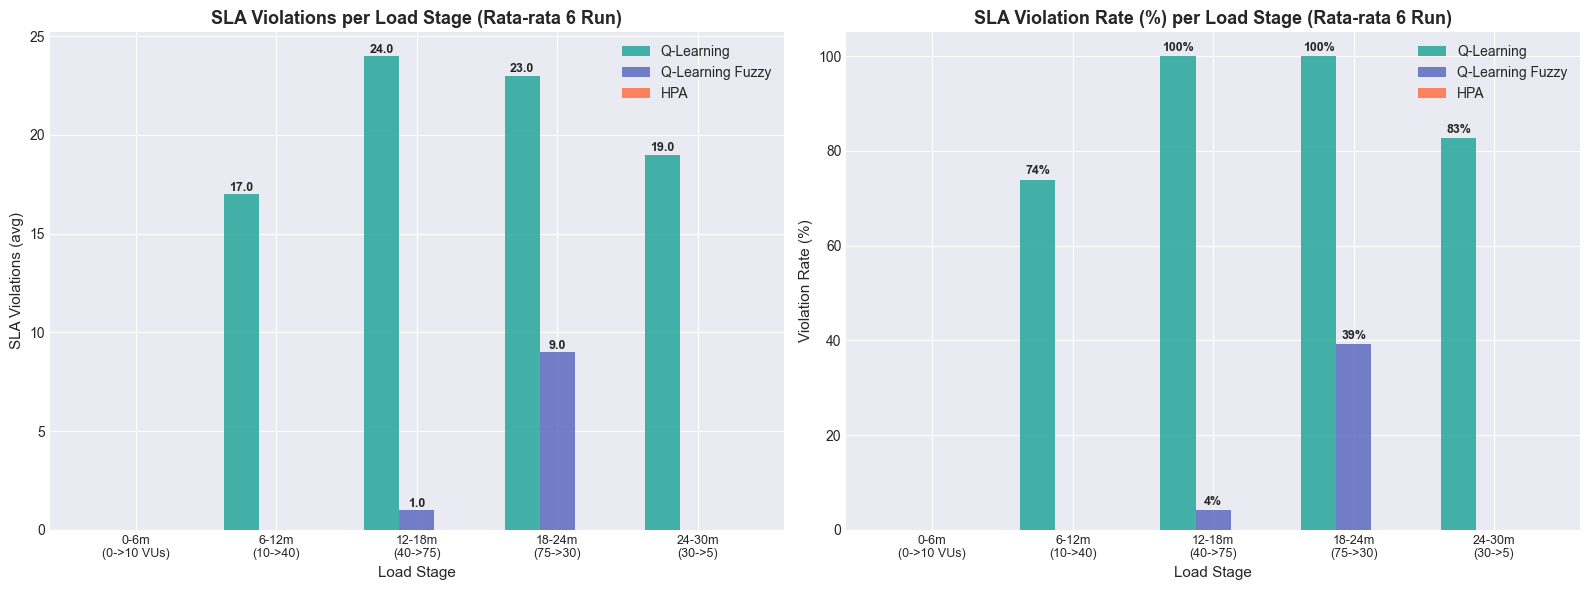


                   SLA VIOLATION SUMMARY (Threshold: 1000 ms)                   

Method                    Total  Compliant   Violated  Violation %
-----------------------------------------------------------------
Q-Learning                  118       35.0       83.0        70.3%
Q-Learning Fuzzy            119      109.0       10.0         8.4%
HPA                         121      121.0        0.0         0.0%

                         SLA Violations per Load Stage                          
--------------------------------------------------------------------------------
Stage                                 Q-Learning       Q-Learning Fuzzy                    HPA
--------------------------------------------------------------------------------
0-6m (0->10 VUs)           0.0/20   (  0.0%)  0.0/21   (  0.0%)  0.0/23   (  0.0%)
6-12m (10->40 VUs)        17.0/23   ( 73.9%)  0.0/23   (  0.0%)  0.0/23   (  0.0%)
12-18m (40->75 VUs)       24.0/24   (100.0%)  1.0/24   (  4.2%)  0.0/24   (  0

In [11]:
SLA_THRESHOLD = 1000  # ms

datasets_sla = [('ql', df_ql, LABELS['ql']), ('qf', df_qf, LABELS['qf']), ('hpa', df_hpa, LABELS['hpa'])]

# --- 1) Overall SLA comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sla_stats = {}
for key, df, label in datasets_sla:
    valid = df['response_time_ms'].notna() & (df['response_time_ms'] > 0)
    total = valid.sum()
    violated = (df.loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
    compliant = total - violated
    pct_violated = violated / total * 100 if total > 0 else 0
    sla_stats[label] = {'total': total, 'violated': violated, 'compliant': compliant,
                         'pct_violated': pct_violated, 'pct_compliant': 100 - pct_violated}

ax = axes[0]
methods = list(sla_stats.keys())
compliant_vals = [sla_stats[m]['compliant'] for m in methods]
violated_vals  = [sla_stats[m]['violated'] for m in methods]
total_vals     = [sla_stats[m]['total'] for m in methods]

x = np.arange(len(methods))
width = 0.5
ax.bar(x, compliant_vals, width, label=f'Compliant (<= {SLA_THRESHOLD} ms)', color='#4CAF50', alpha=0.85)
ax.bar(x, violated_vals, width, bottom=compliant_vals, label=f'Violated (> {SLA_THRESHOLD} ms)', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    v = violated_vals[i]
    t_val = total_vals[i]
    pct = v / t_val * 100 if t_val > 0 else 0
    ax.text(i, t_val + 1, f'{v:.1f}/{t_val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Measurements', fontsize=11)
ax.set_title('SLA Violation Count (Rata-rata 6 Run)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.legend(fontsize=10)

ax = axes[1]
pct_c = [sla_stats[m]['pct_compliant'] for m in methods]
pct_v = [sla_stats[m]['pct_violated'] for m in methods]

ax.barh(x, pct_c, height=0.5, label='Compliant', color='#4CAF50', alpha=0.85)
ax.barh(x, pct_v, height=0.5, left=pct_c, label='Violated', color='#F44336', alpha=0.85)

for i in range(len(methods)):
    if pct_c[i] > 15:
        ax.text(pct_c[i] / 2, i, f'{pct_c[i]:.1f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    if pct_v[i] > 5:
        ax.text(pct_c[i] + pct_v[i] / 2, i, f'{pct_v[i]:.1f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(100.5, i, f'{pct_v[i]:.1f}%', ha='left', va='center', fontsize=10,
                fontweight='bold', color='#F44336')

ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_title('SLA Compliance Rate (%) (Rata-rata 6 Run)', fontsize=13, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(methods, fontsize=11)
ax.set_xlim(0, 110)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

# --- 2) SLA violations per load stage ---
stage_boundaries_min = list(zip(k6_times_min[:-1], k6_times_min[1:]))
stage_names_short = ['0-6m\n(0->10 VUs)', '6-12m\n(10->40)', '12-18m\n(40->75)',
                     '18-24m\n(75->30)', '24-30m\n(30->5)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_stage = np.arange(len(stage_names_short))
width = 0.25

ax = axes[0]
for i, (key, df, label) in enumerate(datasets_sla):
    viol_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        viol = (df.loc[mask].loc[valid, 'response_time_ms'] > SLA_THRESHOLD).sum()
        viol_per_stage.append(viol)
    bars = ax.bar(x_stage + (i - 1) * width, viol_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, viol_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('SLA Violations (avg)', fontsize=11)
ax.set_title('SLA Violations per Load Stage (Rata-rata 6 Run)', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)

ax = axes[1]
for i, (key, df, label) in enumerate(datasets_sla):
    pct_per_stage = []
    for t_start, t_end in stage_boundaries_min:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        pct_per_stage.append(pct)
    bars = ax.bar(x_stage + (i - 1) * width, pct_per_stage, width, label=label, color=COLORS[key], alpha=0.85)
    for bar, val in zip(bars, pct_per_stage):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Load Stage', fontsize=11)
ax.set_ylabel('Violation Rate (%)', fontsize=11)
ax.set_title('SLA Violation Rate (%) per Load Stage (Rata-rata 6 Run)', fontsize=13, fontweight='bold')
ax.set_xticks(x_stage)
ax.set_xticklabels(stage_names_short, fontsize=9)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# --- 3) Summary Table ---
print(f'\n{"=" * 80}')
print(f'{"SLA VIOLATION SUMMARY (Threshold: " + str(SLA_THRESHOLD) + " ms)":^80}')
print(f'{"=" * 80}')
print(f'\n{"Method":<22} {"Total":>8} {"Compliant":>10} {"Violated":>10} {"Violation %":>12}')
print(f'{"-" * 65}')
for label in methods:
    s = sla_stats[label]
    print(f'{label:<22} {s["total"]:>8} {s["compliant"]:>10.1f} {s["violated"]:>10.1f} {s["pct_violated"]:>11.1f}%')

print(f'\n{"SLA Violations per Load Stage":^80}')
print(f'{"-" * 80}')
stage_names_full = ['0-6m (0->10 VUs)', '6-12m (10->40 VUs)', '12-18m (40->75 VUs)',
                    '18-24m (75->30 VUs)', '24-30m (30->5 VUs)']
header = f'{"Stage":<25}'
for key, df, label in datasets_sla:
    header += f' {label:>22}'
print(header)
print(f'{"-" * 80}')
for stage_name, (t_start, t_end) in zip(stage_names_full, stage_boundaries_min):
    row = f'{stage_name:<25}'
    for key, df, label in datasets_sla:
        mask = (df['elapsed_min'] >= t_start) & (df['elapsed_min'] < t_end)
        valid_mask = df.loc[mask, 'response_time_ms'].notna() & (df.loc[mask, 'response_time_ms'] > 0)
        total = valid_mask.sum()
        viol = (df.loc[mask].loc[valid_mask, 'response_time_ms'] > SLA_THRESHOLD).sum()
        pct = viol / total * 100 if total > 0 else 0
        row += f' {viol:>4.1f}/{total:<4} ({pct:>5.1f}%)'
    print(row)